**Visualizations of Class Standing Vs. LLM Product Use Frequency**

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (10).

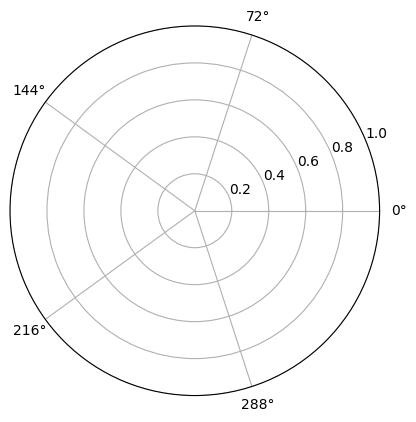

In [ ]:
# SPIDER CHART EXAMPLE: Comparing Iris Flower Species
# This example uses the famous iris dataset to compare three species of iris flowers
# across four key measurements

# Load the iris dataset from sklearn
# The iris dataset contains measurements of 150 iris flowers from three species
iris_data = load_iris()

# Convert to DataFrame for easier manipulation
# Columns: sepal length, sepal width, petal length, petal width
iris = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris['species'] = iris_data.target

# Map species numbers to names for better readability
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris['species'] = iris['species'].map(species_map)

# Calculate mean values for each species (to show their characteristic profiles)
# This gives us the "average" flower measurements for each species
species_means = iris.groupby('species').mean()

# The four metrics (axes) are: Sepal Length, Sepal Width, Petal Length, Petal Width
metrics = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
species_names = species_means.index.tolist()  # ['setosa', 'versicolor', 'virginica']

# Set up the radar chart geometry
num_metrics = len(metrics)  # Number of metrics (4 in this case)

# Create evenly spaced angles for each axis (in radians)
# endpoint=False means we don't duplicate the starting angle
theta = np.linspace(0, 2*np.pi, num_metrics, endpoint=False)

# Close the polygon by appending the first angle at the end
theta = np.concatenate((theta, [theta[0]]))

# Create the polar plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)  # polar=True creates a circular plot

# Plot each species as a separate polygon
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

for i, species in enumerate(species_names):
    # Get the mean values for this species across all 4 metrics
    values = species_means.loc[species].values

    # Close the polygon by appending the first value at the end
    values = np.concatenate((values, [values[0]]))

    # Plot the line connecting all points
    ax.plot(theta, values, linewidth=2.5, linestyle='solid',
            label=species.capitalize(), color=colors[i], marker='o', markersize=8)

    # Fill the area inside the polygon with transparency
    ax.fill(theta, values, alpha=0.15, color=colors[i])

# Customize the plot
ax.set_xticks(theta[:-1])  # Set tick positions (exclude the duplicate last point)
ax.set_xticklabels(['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'],
                   fontsize=11)
ax.set_ylim(0, 8)  # Set radial axis limits to accommodate the data range
ax.grid(True, linestyle='--', alpha=0.7)

# Add legend and title
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title('Spider Chart: Iris Species Comparison by Flower Measurements',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Interpretation:
# - Each colored polygon represents one iris species (Setosa, Versicolor, Virginica)
# - Points farther from the center indicate larger measurements
# - Setosa (blue): Has shorter petals but relatively wider sepals - creates a distinctive shape
# - Versicolor (orange): Intermediate measurements - the "middle" species
# - Virginica (green): Largest overall measurements, especially petal length - largest polygon
# - The different shapes make it easy to see how these species differ from each other
#
# Key Insights:
# - Petal length and width are the most distinctive features (biggest differences)
# - Setosa has notably smaller petals compared to the other two species
# - Virginica tends to have the largest flowers overall